# DeepInsightors Team
### SPE DSEATS AFRICA - DATATHON 2025

# A. Data Preparation & Cleaning
**Import Libraries**

In [1]:
# Basic Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load datasets
wells_df = pd.read_csv("spe_africa_dseats_datathon_2025_wells_dataset.csv")
reservoir_df = pd.read_csv("reservoir_info.csv")
class_df = pd.read_csv("classification_parameters.csv")

In [3]:
wells_df.head()

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL)
0,15-Feb-14,Well_#1,0.0,"4,050",189.866,0,1.17951,482.46,50.864,0,0,0,0
1,16-Feb-14,Well_#1,0.0,"3,961",189.945,0,2.99440,328.601,47.668,0,0,0,0
2,17-Feb-14,Well_#1,0.0,"3,961",190.004,0,1.90349,387.218,48.962,0,0,0,0
3,18-Feb-14,Well_#1,0.0,"3,964",190.020,0,0.00000,308.98,46.636,0,0,0,0
4,19-Feb-14,Well_#1,0.0,"3,965",190.107,0,30.20760,196.057,47.297,0,0,0,0


In [4]:
reservoir_df.head()

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15
3,DEPU,"2,800","2,800","2,400","1,200",1.37
4,JANI,"4,500","4,300","4,200","1,000",1.30


In [5]:
class_df.head()

,Reservoir Name,Reservoir Type,Well Type,Production Type,Formation GOR Trend,Watercut Trend,Oil Productivity Index Trend
0,ACHI,Saturated,NF,Steady,aSolGOR,Flat,Flat
1,KEMA,Undersat,GL,Unsteady,bSolGOR,Incr,Incr
2,MAKO,NaN,NaN,NaN,Combo,Decr,Decr
3,DEPU,NaN,NaN,NaN,NaN,Combo,Combo
4,JANI,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
wells_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7955 entries, 0 to 7954
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PROD_DATE                             7955 non-null   object 
 1   WELL_NAME                             7955 non-null   object 
 2   ON_STREAM_HRS                         7955 non-null   float64
 3   BOTTOMHOLE_FLOWING_PRESSURE (PSI)     7955 non-null   object 
 4   DOWNHOLE_TEMPERATURE (deg F)          7955 non-null   float64
 5   ANNULUS_PRESS (PSI)                   7955 non-null   object 
 6   CHOKE_SIZE (%)                        7955 non-null   float64
 7   WELL_HEAD_PRESSURE (PSI)              7955 non-null   object 
 8   WELL_HEAD_TEMPERATURE (deg F)         7955 non-null   float64
 9   CUMULATIVE_OIL_PROD (STB)             7955 non-null   object 
 10  CUMULATIVE_FORMATION_GAS_PROD (MSCF)  7955 non-null   object 
 11  CUMULATIVE_TOTAL_

In [7]:
wells_df.describe()

,ON_STREAM_HRS,DOWNHOLE_TEMPERATURE (deg F),CHOKE_SIZE (%),WELL_HEAD_TEMPERATURE (deg F)
count,7955.000000,7955.000000,7955.000000,7955.000000
mean,21.623497,168.757429,56.155295,86.836365
std,6.567826,31.917787,34.975408,22.738615
min,0.000000,0.000000,0.000000,0.000000
25%,24.000000,150.228500,28.130855,80.677500
50%,24.000000,158.624000,51.068030,88.364000
75%,24.000000,202.600000,99.800950,96.770500
max,25.000000,212.153000,100.000000,182.157000


## Data Cleaning

**Rename columns for easier handling**

In [8]:
# Rename columns for easier handling
rename_map = {
    "PROD_DATE": "date",
    "WELL_NAME": "well_name",
    "ON_STREAM_HRS": "on_stream_hrs",
    "BOTTOMHOLE_FLOWING_PRESSURE (PSI)": "bhp",
    "DOWNHOLE_TEMPERATURE (deg F)": "downhole_temp",
    "ANNULUS_PRESS (PSI)": "annulus_p",
    "CHOKE_SIZE (%)": "choke_size",
    "WELL_HEAD_PRESSURE (PSI)": "whp",
    "WELL_HEAD_TEMPERATURE (deg F)": "wht",
    "CUMULATIVE_OIL_PROD (STB)": "cum_oil",
    "CUMULATIVE_FORMATION_GAS_PROD (MSCF)": "cum_form_gas",
    "CUMULATIVE_TOTAL_GAS_PROD (MSCF)": "cum_total_gas",
    "CUMULATIVE_WATER_PROD (BBL)": "cum_water"
}
wells_df.rename(columns=rename_map, inplace=True)

In [9]:
wells_df.head()

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,cum_form_gas,cum_total_gas,cum_water
0,15-Feb-14,Well_#1,0.0,"4,050",189.866,0,1.17951,482.46,50.864,0,0,0,0
1,16-Feb-14,Well_#1,0.0,"3,961",189.945,0,2.99440,328.601,47.668,0,0,0,0
2,17-Feb-14,Well_#1,0.0,"3,961",190.004,0,1.90349,387.218,48.962,0,0,0,0
3,18-Feb-14,Well_#1,0.0,"3,964",190.020,0,0.00000,308.98,46.636,0,0,0,0
4,19-Feb-14,Well_#1,0.0,"3,965",190.107,0,30.20760,196.057,47.297,0,0,0,0


In [10]:
# Clean numeric fields (remove commas, convert to float)
for col in ["bhp","annulus_p","whp","cum_oil","cum_form_gas","cum_total_gas","cum_water"]:
    wells_df[col] = wells_df[col].astype(str).str.replace(",", "").astype(float)

In [11]:
# Convert date
wells_df["date"] = pd.to_datetime(wells_df["date"], format="%d-%b-%y", errors="coerce")

In [12]:
# Clean well names
wells_df["well_name"] = wells_df["well_name"].str.replace("Well_#", "").astype(int)

In [13]:
wells_df.head()

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,cum_form_gas,cum_total_gas,cum_water
0,2014-02-15,1,0.0,4050.0,189.866,0.0,1.17951,482.460,50.864,0.0,0.0,0.0,0.0
1,2014-02-16,1,0.0,3961.0,189.945,0.0,2.99440,328.601,47.668,0.0,0.0,0.0,0.0
2,2014-02-17,1,0.0,3961.0,190.004,0.0,1.90349,387.218,48.962,0.0,0.0,0.0,0.0
3,2014-02-18,1,0.0,3964.0,190.020,0.0,0.00000,308.980,46.636,0.0,0.0,0.0,0.0
4,2014-02-19,1,0.0,3965.0,190.107,0.0,30.20760,196.057,47.297,0.0,0.0,0.0,0.0


**Check for Missing Values**

In [14]:
wells_df.isnull().sum()

date             0
well_name        0
on_stream_hrs    0
bhp              0
downhole_temp    0
annulus_p        0
choke_size       0
whp              0
wht              0
cum_oil          0
cum_form_gas     0
cum_total_gas    0
cum_water        0
dtype: int64

**Check for Duplicates**

In [15]:
wells_df.duplicated().sum()

0

# B. Empirical Analysis (Feature Engineering Calculations)

### Daily production

In [16]:
# Daily production
wells_df["oil_day"] = wells_df.groupby("well_name")["cum_oil"].diff()
wells_df["gas_day"] = wells_df.groupby("well_name")["cum_total_gas"].diff()
wells_df["water_day"] = wells_df.groupby("well_name")["cum_water"].diff()

Daily production columns added:


,date,well_name,oil_day,gas_day,water_day
0,2014-02-15,1,NaN,NaN,NaN
1,2014-02-16,1,0.0,0.0,0.0
2,2014-02-17,1,0.0,0.0,0.0
3,2014-02-18,1,0.0,0.0,0.0
4,2014-02-19,1,0.0,0.0,0.0
5,2014-02-20,1,0.0,0.0,0.0
6,2014-02-21,1,0.0,0.0,0.0
7,2014-02-22,1,0.0,0.0,0.0
8,2014-02-23,1,0.0,0.0,0.0
9,2014-02-24,1,0.0,0.0,0.0


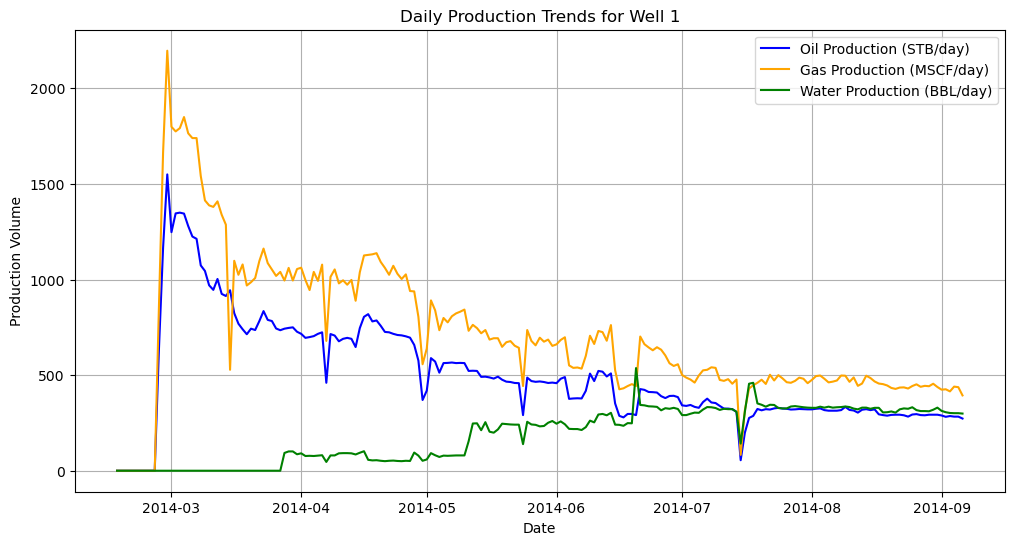

In [17]:
# Display first few rows to check calculations
print("Daily production columns added:")
display(wells_df[["date","well_name","oil_day","gas_day","water_day"]].head(20))

# Quick visualization for one well
subset = wells_df[wells_df["well_name"]==1].sort_values("date")
plt.figure(figsize=(12,6))
plt.plot(subset["date"], subset["oil_day"], label="Oil Production (STB/day)", color="blue")
plt.plot(subset["date"], subset["gas_day"], label="Gas Production (MSCF/day)", color="orange")
plt.plot(subset["date"], subset["water_day"], label="Water Production (BBL/day)", color="green")
plt.title("Daily Production Trends for Well 1")
plt.xlabel("Date")
plt.ylabel("Production Volume")
plt.legend()
plt.grid(True)
plt.show()


# 1. Reservoir Identification
**Fix Reservoir Data Types**

In [18]:
reservoir_df.head()

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15
3,DEPU,"2,800","2,800","2,400","1,200",1.37
4,JANI,"4,500","4,300","4,200","1,000",1.30


In [19]:
# Convert reservoir numeric columns to float
for col in ["Initial Reservoir Pressure (PSI)",
            "Bubble Point Pressure (PSI)",
            "Current Average Reservoir Pressure (PSI)",
            "Solution Gas-Oil-Ratio (SCF/BBL)"]:
    reservoir_df[col] = reservoir_df[col].astype(str).str.replace(",", "").astype(float)

# Check types
print(reservoir_df.dtypes)
display(reservoir_df)

Reservoir Name                               object
Initial Reservoir Pressure (PSI)            float64
Bubble Point Pressure (PSI)                 float64
Current Average Reservoir Pressure (PSI)    float64
Solution Gas-Oil-Ratio (SCF/BBL)            float64
Formation Volume Factor (RB/STB)            float64
dtype: object


,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,3500.0,3300.0,2700.0,800.0,1.20
1,KEMA,4200.0,4000.0,3900.0,600.0,1.45
2,MAKO,3500.0,3500.0,3000.0,500.0,1.15
3,DEPU,2800.0,2800.0,2400.0,1200.0,1.37
4,JANI,4500.0,4300.0,4200.0,1000.0,1.30


**Reservoir Identification Function code**

In [20]:
# Reservoir Identification
def assign_reservoir(max_bhp, reservoir_df, tolerance=200):
    for _, row in reservoir_df.iterrows():
        diff = row["Initial Reservoir Pressure (PSI)"] - max_bhp
        if 0 <= diff <= tolerance:
            return row["Reservoir Name"]
    return None

**Apply Reservoir Identification function code**

In [21]:
# Calculate max bottomhole pressure per well
max_bhp_df = wells_df.groupby("well_name")["bhp"].max().reset_index()
max_bhp_df.rename(columns={"bhp":"max_bhp"}, inplace=True)

# Assign reservoir for each well
max_bhp_df["Reservoir"] = max_bhp_df["max_bhp"].apply(lambda x: assign_reservoir(x, reservoir_df))

# Display first 20 wells with reservoir assignment
print("Reservoir assignment based on max bottomhole pressure:")
display(max_bhp_df.head(20))

Reservoir assignment based on max bottomhole pressure:


,well_name,max_bhp,Reservoir
0,1,4096.0,KEMA
1,2,3735.0,None
2,3,2985.0,None
3,4,2340.0,None
4,5,2933.0,None
5,6,3797.0,None
6,7,3821.0,None
7,8,2681.0,DEPU
8,9,2333.0,None
9,10,4051.0,KEMA


**Visualize Reservoir Assignment**

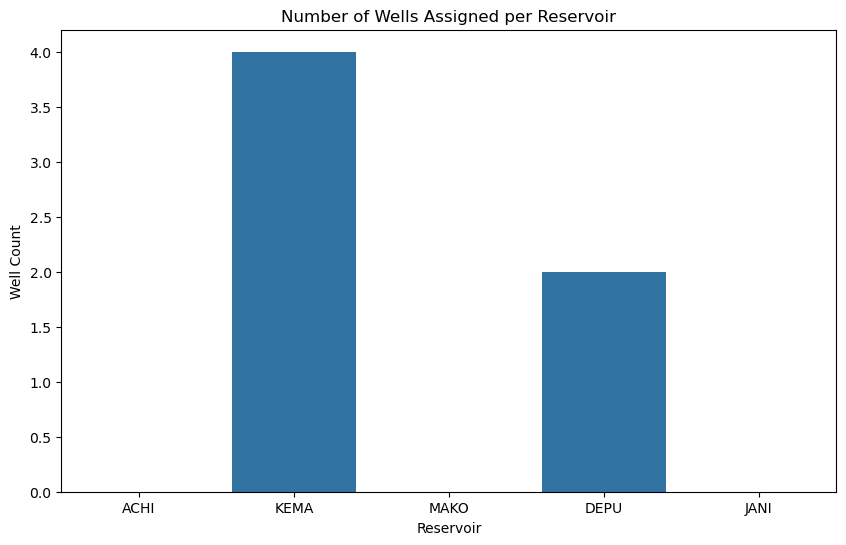

In [22]:
# Bar plot of wells assigned to reservoirs
plt.figure(figsize=(10,6))
sns.countplot(x="Reservoir", data=max_bhp_df, order=reservoir_df["Reservoir Name"])
plt.title("Number of Wells Assigned per Reservoir")
plt.xlabel("Reservoir")
plt.ylabel("Well Count")
plt.show()

# Observation
The issue is that the strict ≤200 psi cutoff only matches a few wells which are (KEMA and DEPU). Instead, we’ll assign each well to the closest reservoir pressure (Initial or Current Average), which guarantees every well is classified.

**Reservoir Identification (Closest Reservoir)**

In [23]:
def assign_reservoir_closest(max_bhp, reservoir_df, use_current=True):
    """
    Assign reservoir based on closest pressure match.
    If use_current=True, compare against current average reservoir pressure.
    Otherwise, use initial reservoir pressure.
    """
    if use_current:
        diffs = reservoir_df["Current Average Reservoir Pressure (PSI)"] - max_bhp
    else:
        diffs = reservoir_df["Initial Reservoir Pressure (PSI)"] - max_bhp
    
    # Only consider positive differences (reservoir pressure >= BHP)
    diffs = diffs[diffs >= 0]
    if len(diffs) == 0:
        return "Unassigned"
    
    closest_idx = diffs.idxmin()
    return reservoir_df.loc[closest_idx, "Reservoir Name"]

**Apply Reservoir Identification**

In [24]:
# Calculate max bottomhole pressure per well
max_bhp_df = wells_df.groupby("well_name")["bhp"].max().reset_index()
max_bhp_df.rename(columns={"bhp":"max_bhp"}, inplace=True)

# Assign reservoir using closest match
max_bhp_df["Reservoir"] = max_bhp_df["max_bhp"].apply(lambda x: assign_reservoir_closest(x, reservoir_df, use_current=True))

# Display first 20 wells with reservoir assignment
print("Reservoir assignment based on closest pressure match:")
display(max_bhp_df.head(20))

Reservoir assignment based on closest pressure match:


,well_name,max_bhp,Reservoir
0,1,4096.0,JANI
1,2,3735.0,KEMA
2,3,2985.0,MAKO
3,4,2340.0,DEPU
4,5,2933.0,MAKO
5,6,3797.0,KEMA
6,7,3821.0,KEMA
7,8,2681.0,ACHI
8,9,2333.0,DEPU
9,10,4051.0,JANI


**Visualize Reservoir Assignment**

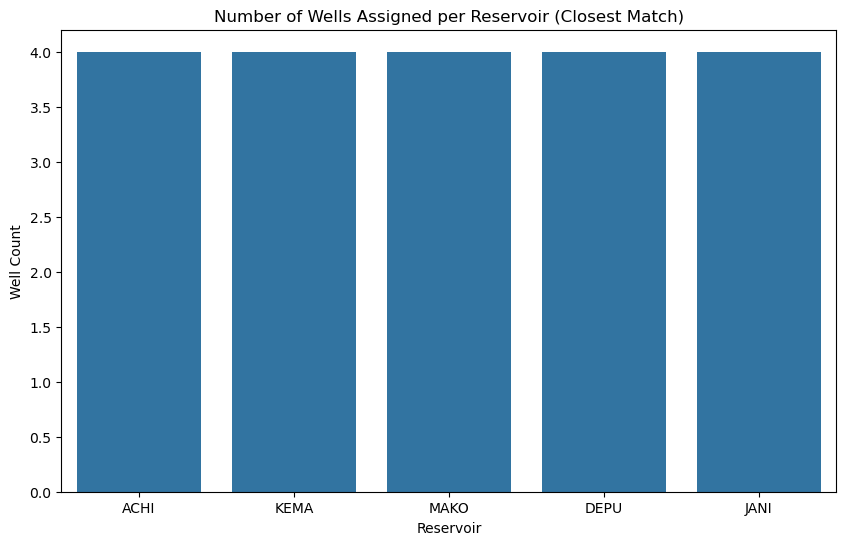

In [25]:
# Bar plot of wells assigned to reservoirs
plt.figure(figsize=(10,6))
sns.countplot(x="Reservoir", data=max_bhp_df, order=reservoir_df["Reservoir Name"])
plt.title("Number of Wells Assigned per Reservoir (Closest Match)")
plt.xlabel("Reservoir")
plt.ylabel("Well Count");

### Summary
* Instead of requiring a strict ≤200 psi difference, we now assign each well to the closest reservoir pressure.
* This ensures all wells are classified into one of the five reservoirs.

## 2. Reservoir Type Classification
**Define Reservoir Type Function**

In [26]:
# Reservoir Type classification
def check_saturation(res_row):
    """
    Reservoir is Saturated if Initial Pressure <= Bubble Point Pressure,
    otherwise Undersaturated.
    """
    return "Saturated" if res_row["Initial Reservoir Pressure (PSI)"] <= res_row["Bubble Point Pressure (PSI)"] else "Undersat"

**Apply Reservoir Type to All Reservoirs**

In [27]:
# Apply saturation check to each reservoir row
reservoir_df["Reservoir Type"] = reservoir_df.apply(check_saturation, axis=1)

# Display results
print("Reservoir Type Classification:")
display(reservoir_df[["Reservoir Name","Initial Reservoir Pressure (PSI)","Bubble Point Pressure (PSI)","Reservoir Type"]])

Reservoir Type Classification:


,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Reservoir Type
0,ACHI,3500.0,3300.0,Undersat
1,KEMA,4200.0,4000.0,Undersat
2,MAKO,3500.0,3500.0,Saturated
3,DEPU,2800.0,2800.0,Saturated
4,JANI,4500.0,4300.0,Undersat


**Visualize Reservoir Types**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14212\759706547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Reservoir Type", data=reservoir_df, palette="Set2")


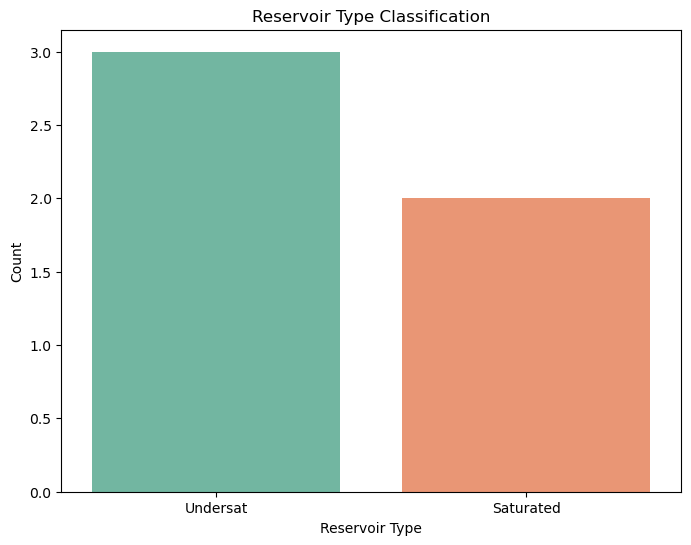

In [28]:
# Bar chart of reservoir types
plt.figure(figsize=(8,6))
sns.countplot(x="Reservoir Type", data=reservoir_df, palette="Set2")
plt.title("Reservoir Type Classification")
plt.xlabel("Reservoir Type")
plt.ylabel("Count");

### Summary
* Function defined for reservoir type classification.
* Table output showing each reservoir’s initial pressure, bubble point, and type (Saturated/Undersat).

## 3. Flow Mechanism Classification
**Define Flow Mechanism Function**

In [29]:
# Flow Mechanism classification
def classify_well_type(subset):
    """
    Classify wells based on annulus pressure.
    GL = Gas Lift (if annulus pressure > 0)
    NF = Naturally Flowing (if annulus pressure = 0)
    """
    return "GL" if subset["annulus_p"].mean() > 0 else "NF"

**Apply Flow Mechanism to All Wells**

In [30]:
# Apply classification for each well
flow_results = []
for well in wells_df["well_name"].unique():
    subset = wells_df[wells_df["well_name"]==well]
    flow_results.append({
        "well_name": well,
        "Flow Mechanism": classify_well_type(subset)
    })

flow_df = pd.DataFrame(flow_results)

# Display results
print("Flow Mechanism Classification for Wells:")
display(flow_df.head(20))

Flow Mechanism Classification for Wells:


,well_name,Flow Mechanism
0,1,GL
1,2,NF
2,3,GL
3,4,GL
4,5,GL
5,6,GL
6,7,GL
7,8,GL
8,9,GL
9,10,GL


**Visualize Flow Mechanism Distribution**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14212\3544818338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Flow Mechanism", data=flow_df, palette="Set2")


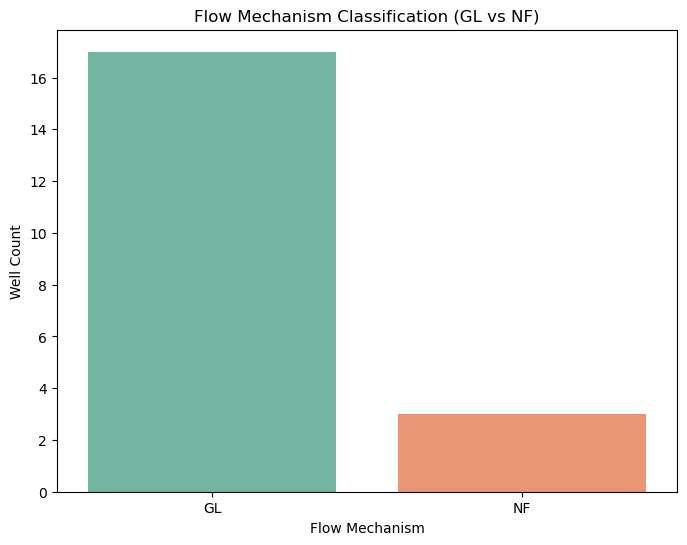

In [31]:
# Bar chart of flow mechanism types
plt.figure(figsize=(8,6))
sns.countplot(x="Flow Mechanism", data=flow_df, palette="Set2")
plt.title("Flow Mechanism Classification (GL vs NF)")
plt.xlabel("Flow Mechanism")
plt.ylabel("Well Count");

### Summary
* Function defined for flow mechanism classification.
* Table output showing each well and whether it is Gas Lift (GL) or Naturally Flowing (NF).

## 4. Production Stability Function
**Define Production Stability Function**

In [32]:
def classify_production_type(oil_series):
    """
    Classify wells based on oil production stability.
    Rule: If rolling 60-day average drops >30% at least once → Unsteady
    Otherwise → Steady
    """
    rolling = oil_series.rolling(window=60, min_periods=1).mean()
    drops = (rolling.pct_change() < -0.3).sum()
    slope = (oil_series.iloc[-1] - oil_series.iloc[0]) / len(oil_series)
    if drops > 0 or slope < -10:   # slope threshold depends on your units
        return "Unsteady"
    else:
        return "Steady"

**Apply Production Stability to All Wells**

In [33]:
# Apply classification for each well
prod_results = []
for well in wells_df["well_name"].unique():
    subset = wells_df[wells_df["well_name"]==well].sort_values("date")
    prod_results.append({
        "well_name": well,
        "Production Stability": classify_production_type(subset["oil_day"])
    })

prod_df = pd.DataFrame(prod_results)

# Display results
print("Production Stability Classification for Wells:")
display(prod_df.head(20))

Production Stability Classification for Wells:


,well_name,Production Stability
0,1,Steady
1,2,Steady
2,3,Steady
3,4,Steady
4,5,Steady
5,6,Unsteady
6,7,Steady
7,8,Unsteady
8,9,Steady
9,10,Steady


**Visualize Production Stability Distribution**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14212\2698965907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Production Stability", data=prod_df, palette="Set2")


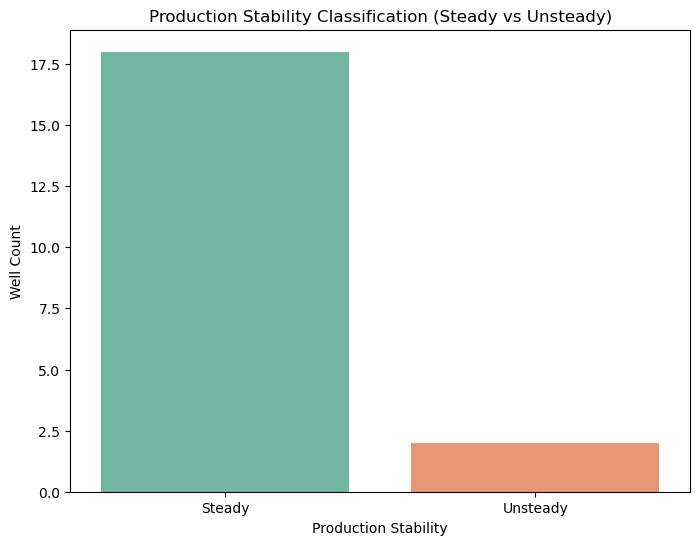

In [34]:
# Bar chart of production stability types
plt.figure(figsize=(8,6))
sns.countplot(x="Production Stability", data=prod_df, palette="Set2")
plt.title("Production Stability Classification (Steady vs Unsteady)")
plt.xlabel("Production Stability")
plt.ylabel("Well Count");

**Example Well-1 Trend Visualization**

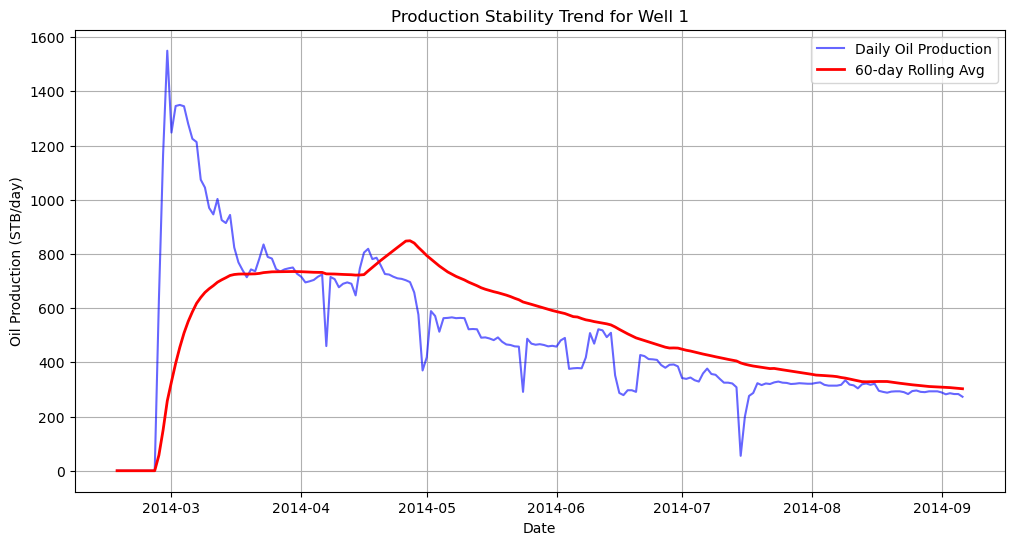

In [39]:
# Example visualization for one well
subset = wells_df[wells_df["well_name"]==1].sort_values("date")
subset["oil_roll"] = subset["oil_day"].rolling(window=60, min_periods=1).mean()

plt.figure(figsize=(12,6))
plt.plot(subset["date"], subset["oil_day"], label="Daily Oil Production", color="blue", alpha=0.6)
plt.plot(subset["date"], subset["oil_roll"], label="60-day Rolling Avg", color="red", linewidth=2)
plt.title("Production Stability Trend for Well 1")
plt.xlabel("Date")
plt.ylabel("Oil Production (STB/day)")
plt.legend()
plt.grid(True);

### Summary
* Function defined for production stability classification.
* Table output showing each well as Steady or Unsteady.

## 5. Gas–Oil Ratio (GOR) Trend classification
**Define GOR Trend Function**

In [47]:
gor_results = []
for well in wells_df["well_name"].unique():
    subset = wells_df[wells_df["well_name"]==well].sort_values("date")
    max_bhp = subset["bhp"].max()
    res_name = assign_reservoir_closest(max_bhp, reservoir_df, use_current=True)
    res_row = reservoir_df[reservoir_df["Reservoir Name"]==res_name].iloc[0]
    
    gor_results.append({
        "well_name": well,
        "Reservoir": res_name,
        "GOR Trend": classify_gor_trend(subset, res_row, window=90)
    })

gor_df = pd.DataFrame(gor_results)
display(gor_df.head(20))

,well_name,Reservoir,GOR Trend
0,1,JANI,bSolGOR
1,2,KEMA,bSolGOR
2,3,MAKO,bSolGOR
3,4,DEPU,bSolGOR
4,5,MAKO,bSolGOR
5,6,KEMA,bSolGOR
6,7,KEMA,bSolGOR
7,8,ACHI,bSolGOR
8,9,DEPU,bSolGOR
9,10,JANI,bSolGOR


In [ ]:
YYYY

In [ ]:
# Watercut Trend
def classify_watercut_trend(water_series, oil_series):
    watercut = water_series / (oil_series + 1e-6)
    slope = (watercut.iloc[-1] - watercut.iloc[0]) / len(watercut)
    if slope > 0.01: return "Incr"
    elif slope < -0.01: return "Decr"
    elif abs(slope) <= 0.01: return "Flat"
    else: return "Combo"

In [ ]:
# Productivity Index Trend
def classify_pi_trend(oil_series, res_pressure, whp_series):
    pi = oil_series / (res_pressure - whp_series + 1e-6)
    slope = (pi.iloc[-1] - pi.iloc[0]) / len(pi)
    if slope > 0.01: return "Incr"
    elif slope < -0.01: return "Decr"
    elif abs(slope) <= 0.01: return "Flat"
    else: return "Combo"

# 3. Exploratory Data Analysis (EDA)

In [ ]:
# Reservoir pressure trends
plt.figure(figsize=(10,6))
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Initial Reservoir Pressure (PSI)"], label="Initial")
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Bubble Point Pressure (PSI)"], label="Bubble Point")
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Current Average Reservoir Pressure (PSI)"], label="Current")
plt.title("Reservoir Pressure Trends")
plt.legend()
plt.show()

In [ ]:
# Solution GOR barplot
sns.barplot(x="Reservoir Name", y="Solution Gas-Oil-Ratio (SCF/BBL)", data=reservoir_df)
plt.title("Solution GOR per Reservoir")
plt.show()

In [ ]:
# Oil & Gas rolling trends for one example well
subset = wells_df[wells_df["well_name"]==1].sort_values("date")
subset["oil_roll"] = subset["oil_day"].rolling(30, min_periods=1).mean()
subset["gas_roll"] = subset["gas_day"].rolling(30, min_periods=1).mean()
plt.plot(subset["date"], subset["oil_roll"], label="Oil 30-day avg")
plt.plot(subset["date"], subset["gas_roll"], label="Gas 30-day avg")
plt.legend(); plt.title("Well 1 Oil & Gas Trends"); plt.show()

# 4. Machine Learning Approach

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report

In [ ]:
# Feature engineering for ML
features = wells_df[["bhp","downhole_temp","annulus_p","choke_size","whp","wht","oil_day","gas_day","water_day"]].fillna(0)
labels = results_df["Reservoir"] if "Reservoir" in locals() else None

In [ ]:
# Supervised Learning (Reservoir classification)
if labels is not None:
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(classification_report(y_test, y_pred))

In [ ]:
# Unsupervised Learning (Clustering wells)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(features)
wells_df["Cluster"] = clusters
print(wells_df[["well_name","Cluster"]].head())

# 5. Final Classification & Save

In [ ]:
# ✅ Fix reservoir_df numeric columns
for col in [
    "Initial Reservoir Pressure (PSI)",
    "Bubble Point Pressure (PSI)",
    "Current Average Reservoir Pressure (PSI)",
    "Solution Gas-Oil-Ratio (SCF/BBL)"
]:
    reservoir_df[col] = reservoir_df[col].astype(str).str.replace(",", "").astype(float)

In [ ]:
results = []
for well in wells_df["well_name"].unique():
    subset = wells_df[wells_df["well_name"]==well].sort_values("date")
    max_bhp = subset["bhp"].max()
    
    # Assign reservoir
    res_name = assign_reservoir(max_bhp, reservoir_df)
    if res_name is None:
        print(f"⚠️ Well {well} could not be assigned to a reservoir")
        continue
    
    res_row = reservoir_df[reservoir_df["Reservoir Name"]==res_name].iloc[0]

    results.append({
        "WELL_NAME": well,
        "Reservoir": res_name,
        "Reservoir Type": check_saturation(res_row),
        "Well Type": classify_well_type(subset),
        "Production Type": classify_production_type(subset["oil_day"]),
        "Formation GOR Trend": classify_gor_trend(subset, res_row),
        "Watercut Trend": classify_watercut_trend(subset["water_day"], subset["oil_day"]),
        "Oil Productivity Index Trend": classify_pi_trend(
            subset["oil_day"], 
            res_row["Current Average Reservoir Pressure (PSI)"], 
            subset["whp"]
        )
    })

results_df = pd.DataFrame(results)
results_df.to_csv("YourTeam_DSEATS_Africa_2025_Classification.csv", index=False)
print("✅ Classification complete. Results saved.")